# QPGP base functions

In [3]:
import numpy as np
from numpy.random import multivariate_normal as mvnrnd
from scipy.linalg import toeplitz, solve_triangular, solve_toeplitz, cholesky, inv
from numpy.fft import fft, ifft


def QPGP_sim(n, p, w,Kappa):
    """
    Simulates a quasi-periodic Gaussian process (QPGP).

    Parameters:
    - n     : int, total length of time series
    - p     : int, periodicity parameter
    - w : float, autoregressive weight
    - Kappa  : covariance matrix

    Returns:
    - X     : np.ndarray of shape (n,), simulated QPGP series
    """

    # Number of blocks
    k = n // p

    # Preallocate X
    if n % p == 0:
        X = np.zeros(n)
        # First block ~ N(0, Kappa / (1 - w^2))
        X[:p] = mvnrnd(mean=np.zeros(p), cov=Kappa / (1 - w**2))
        for i in range(1, k):
            prev = X[(i-1)*p : i*p]
            noise = mvnrnd(mean=np.zeros(p), cov=Kappa)
            X[i*p : (i+1)*p] = w * prev + noise
    else:
        X = np.zeros((k+1)*p)
        X[:p] = mvnrnd(mean=np.zeros(p), cov=Kappa / (1 - w**2))
        for i in range(1, k+1):
            prev = X[(i-1)*p : i*p]
            noise = mvnrnd(mean=np.zeros(p), cov=Kappa)
            X[i*p : (i+1)*p] = w * prev + noise
        X = X[:n]

    return X

def logL(n, p, w, Kappa, X):
    """
    Computes the log-likelihood for block-wise Gaussian model using
    Toeplitz Cholesky factorization.

    Parameters:
    - n     : int, total length of vector X
    - p     : int, block size
    - w     : float, autoregressive coefficient
    - Kappa : np.ndarray (p x p), Toeplitz covariance matrix
    - X     : np.ndarray of shape (n,), data vector

    Returns:
    - logL  : float, computed log-likelihood
    """
    # add small jitter to Kappa
    Kappa = Kappa + 1e-10 * np.eye(p)

    # Get first column of the Toeplitz matrix
    c = Kappa[:, 0]

    # Compute Toeplitz Cholesky factor: Kappa = L L^T

    L = cholesky(Kappa, lower=True)

    # Number of blocks
    k = n // p
    sum_term = 0.0

    # Loop over blocks
    for i in range(1, k):
        X_curr = X[i*p : (i+1)*p]
        X_prev = X[(i-1)*p : i*p]
        diff = X_curr - w * X_prev

        # Efficiently solve Kappa^{-1} diff
        sol = solve_toeplitz((c, c), diff)
        sum_term += diff @ sol    # Compute log-determinant from Cholesky diagonal

    logdet_Kappa = 2 * np.sum(np.log(np.diag(L)))

    # Log-likelihood (negative)
    log_likelihood = ((k - 1) * p * np.log(2 * np.pi)) / 2 + ((k - 1) * logdet_Kappa) / 2 + sum_term

    # Handle numerical issues
    if np.isnan(log_likelihood) or log_likelihood < -1e10:
        return np.inf
    else:
        return log_likelihood


def w_est(n, p, Kappa, X):
    """
    Estimates the autoregressive parameter omega.

    Parameters:
    - n     : int, number of observations
    - p     : int, block size
    - Kappa : np.ndarra
    y (p x p), covariance matrix
    - X     : np.ndarray (n,), data vector

    Returns:
    - w_est : float, estimated omega
    """
    k = n // p
    Kappa = Kappa + 1e-6*np.eye(Kappa.shape[0])
    # Spectral decomposition of Kappa
    eig_vals, U = np.linalg.eigh(Kappa)
    Kappa_inv = U @ np.diag(1.0 / eig_vals) @ U.T

    # Numerator (i1i)
    i1i = 0.0
    for i in range(1, k):
        x1 = X[(i-1)*p - p : (i-1)*p] if i > 1 else X[0:p]
        x2 = X[(i)*p - p : (i)*p]
        i1i += x1.T @ Kappa_inv @ x2

    # Denominator (ii)
    ii = 0.0
    for i in range(k - 1):
        x = X[i*p : (i+1)*p]
        ii += x.T @ Kappa_inv @ x

    # If n is not divisible by p, include the remainder part
    if n % p != 0:
        Kappastar = Kappa[0:(n - k*p), 0:(n - k*p)]
        eig_vals_star, U_star = np.linalg.eigh(Kappastar)
        Kappastar_inv = U_star @ np.diag(1.0 / eig_vals_star) @ U_star.T

        xi = X[k*p - p : n - p]
        xi1 = X[k*p : n]
        nstar = xi.T @ Kappastar_inv @ xi1
        dstar = xi.T @ Kappastar_inv @ xi
    else:
        nstar = 0.0
        dstar = 0.0

    # Final omega estimate
    return (i1i + nstar) / (ii + dstar)


def Kappa_est(n, p, omega, X):
    """
    Direct translation of MATLAB Kappa_est.
    Inputs:
        n     : Number of observations
        p     : Block size
        omega : Weight parameter
        X     : Data vector (1D numpy array)
    Output:
        Kappa_est : Estimated covariance matrix (p x p)
    """
    k = n // p             # floor(n / p)
    l = n - k * p          # remainder length

    S = np.zeros((p, p))   # Initialize S matrix
    S_new = np.zeros((p, p))

    # Create Y matrix from X (reshape like MATLAB)
    Y = X[:k*p].reshape((p, k), order='F')
    if l > 0:
        last_col = np.full((p, 1), np.nan)
        last_col[:l, 0] = X[k*p:]
        Y = np.hstack((Y, last_col))

    # Difference matrix
    Y_matrix = Y[:, 1:] - omega * Y[:, :-1]

    # Loop through blocks to compute S
    for i in range(1, k):
        x_current = X[i*p : (i+1)*p]
        x_prev = X[(i-1)*p : i*p]
        residual = x_current - omega * x_prev
        S += np.outer(residual, residual)

    if n % p == 0:
        S /= (k - 1)
    else:
        S = np.zeros((p, p))

        Y_matrix1 = Y_matrix[:l, :k-1]
        Y_matrix2 = Y_matrix[l:, :k-1]

        S11 = (Y_matrix1 @ Y_matrix1.T) / (k - 1)
        S12 = (Y_matrix1 @ Y_matrix2.T) / (k - 1)
        S21 = S12.T
        S22 = (Y_matrix2 @ Y_matrix2.T) / (k - 1)

        add = np.outer(Y[:l, k], Y[:l, k])
        S11star = ((k - 1) * S11 + add) / k

        S_new[:l, :l] = S11star
        S_new[:l, l:] = S11star @ inv(S11) @ S12
        S_new[l:, :l] = S_new[:l, l:].T
        S_new[l:, l:] = S22 - S21 @ inv(S11) @ S12 \
                        + S21 @ inv(S11) @ S11star @ inv(S11) @ S12

        S = S_new

    # Enforce Toeplitz structure by averaging diagonals
    m, n_ = S.shape
    for d in range(-(m-1), n_):
        indices = [(i, i - d) for i in range(m) if 0 <= i - d < n_]
        diag_vals = [S[i, j] for i, j in indices]
        avg_val = np.mean(diag_vals)
        for i, j in indices:
            S[i, j] = avg_val

    # Ensure positive definiteness via spectral fix
    epsilon = 1e-6
    f = np.real(fft(S[0, :]))
    f[f < 0] = 0
    f = np.abs(f)
    f = np.maximum(f, epsilon)
    v = np.real(ifft(f))

    return toeplitz(v)

def w_Kappa_est(n, p, X, max_iter=200, tol=1e-5):
    """
    Iteratively estimates omega and Kappa covariance matrix.

    Parameters:
    - n        : int, number of observations
    - p        : int, block size
    - X        : np.ndarray (n,), data vector
    - max_iter : int, max number of iterations (default 200)
    - tol      : float, convergence tolerance (default 1e-5)

    Returns:
    - result : dict with keys:
        'w'     : estimated omega
        'Kappa' : estimated covariance matrix
    """
    Kappa_hat = []
    w_hat = []
    l =[]

    Kappa_hat.append(np.eye(p))
    w_hat.append(w_est(n, p, Kappa_hat[0], X))

    for i in range(1, max_iter):
       # print(f"Loop iteration: {i}")
        a = Kappa_est(n, p, w_hat[i-1], X)
        Kappa_hat.append(a)
        b = w_est(n, p, Kappa_hat[i], X)
        w_hat.append(b)
        c=logL(n, p, b, a, X)
        l.append(c)
        if i > 1 and abs(l[-1] - l[-2]) < tol:
            break

    last_iter = i
    w_final = w_hat[last_iter]
    Kappa_final = Kappa_hat[last_iter]

    return {'w': w_final, 'Kappa': Kappa_final}


def par_est(n, p_search, X):
    """
    Estimate the best (p, omega, Kappa) by maximizing the log-likelihood.

    Parameters:
    - n         : int, length of data
    - p_search  : list or array of candidate p values
    - X         : (n,) numpy array of data

    Returns:
    - result: dict with keys:
        - 'p'      : estimated p
        - 'w'      : estimated omega
        - 'Kappa'  : estimated Kappa matrix (2D numpy array)
    """
    logL_vals = []

    for p in p_search:
        var = w_Kappa_est(n, p, X)
        w = var['w']
        Kappa = var['Kappa']
        logL_val = logL(n, p, w, Kappa, X)
        logL_vals.append(logL_val)

    best_idx = np.argmin(logL_vals)
    p_est = p_search[best_idx]

    final = w_Kappa_est(n, p_est, X)
    result = {
        'p': p_est,
        'w': final['w'],
        'Kappa': final['Kappa']
    }

    return result

# write a pred_element func 

def pred_element(n, p, w, Kappa, X):
    t = n + 1
    i = int(np.floor(t / p))
    l = t - i*p
    l = l if l > 0 else p  # handle exact multiples of p

    # l==1: simple AR prediction
    if l == 1:
        return w * X[n - p]

    # covariance correction
    K00 = Kappa[:l-1, :l-1] + 1e-6 * np.eye(l-1)
    K01 = Kappa[0, :l-1]

    # last l-1 elements of previous block
    start_prev = (i-1) * p
    X_prev_block = X[start_prev : start_prev + l-1]

    # last l-1 observed elements (from current block)
    X_curr_block = X[-(l-1):]

    block_diff = X_curr_block - w * X_prev_block
    pred = w * X[n - p] + K01.T @ np.linalg.solve(K00, block_diff)
    
    return pred


def pred_block(n, p, w, X):
   # pred = np.zeros(p)
    pred = w*X[-p:]
    return pred

# Race car simulator 

In [4]:
# A race line to drive on
import numpy as np

def create_race_track(n_points, desired_length):
    # Base parameter
    s = np.linspace(0, 2 * np.pi, n_points)

    # Radial function with more harmonics for complexity
    R = 10 + 2 * np.sin(2 * s) + np.sin(3 * s)
     #10 \
        #+ 2 * np.sin(2 * s) #\
        #+ 1.5 * np.sin(2 * s+0.5)
    # Generate x,y coordinates
    x = R * np.cos(s)
    y = R * np.sin(s)

    # Compute current track length
    dx = np.diff(x, append=x[0])
    dy = np.diff(y, append=y[0])
    length = np.sum(np.sqrt(dx**2 + dy**2))

    # Scale to desired length
    scale = desired_length / length
    x *= scale
    y *= scale

    return x, y


# Helper to find the closest point on the raceline
def find_nearest_index(x_ref, y_ref, x, y):
    dists = np.sqrt((x_ref - x)**2 + (y_ref - y)**2)
    return np.argmin(dists)

# Path deviation error
def signed_lateral_error(x_ref, y_ref, x, y):
    idx = find_nearest_index(x_ref, y_ref, x, y)
    n = len(x_ref)
    # Tangent vector by finite difference
    if idx == 0:
        dx = x_ref[1] - x_ref[0]
        dy = y_ref[1] - y_ref[0]
    elif idx == n - 1:
        dx = x_ref[-1] - x_ref[-2]
        dy = y_ref[-1] - y_ref[-2]
    else:
        dx = x_ref[idx+1] - x_ref[idx-1]
        dy = y_ref[idx+1] - y_ref[idx-1]

    tangent = np.array([dx, dy])
    tangent /= np.linalg.norm(tangent)

    normal = np.array([-tangent[1], tangent[0]])  # Left normal

    vec = np.array([x - x_ref[idx], y - y_ref[idx]])

    e_lat = np.dot(vec, normal)
    return e_lat

# Control strategy - steer towards a point on the raceline
def pure_pursuit_steering(x_ref, y_ref, x, y, theta, L, index):
    nearest_idx = index+1
    path_length = len(x_ref)

    total_dist = 0
    lookahead_idx = nearest_idx
    dx = x_ref[nearest_idx] - x_ref[index]
    dy = y_ref[nearest_idx] - y_ref[index]
    segment_dist = np.sqrt(dx*dx + dy*dy)


    lx = x_ref[lookahead_idx]
    ly = y_ref[lookahead_idx]

    dx = lx - x
    dy = ly - y
    path_angle = np.arctan2(dy, dx)
    alpha = path_angle - theta
    alpha = (alpha + np.pi) % (2 * np.pi) - np.pi

    delta = np.arctan2(2 * L * np.sin(alpha), segment_dist)
    return delta

# A vehicle simualtor - model noise is added to simulate unknown dynamics
def simulate_car(x0, y0, theta0, v, delta_ff, x_ref, y_ref, dt, steps, L=0.5):
    x = np.zeros(steps)
    y = np.zeros(steps)
    theta = np.zeros(steps)
    delta_actual = np.zeros(steps)
    x[0] = x0
    y[0] = y0
    theta[0] = theta0
    # Unknown dynamics parameters
    steering_gain_error = 0.7    # steering is 80% effective
    heading_drift = 0.04         # small heading drift (rad per timestep)
    noise_std = 0.015            # small gaussian noise on steering
    systematic_bias = 0.15       # constant bias in steering (rad)
    bias_slope = 0.01           # optional: slowly increasing bias over trajectory
    for k in range(steps - 1):
        # Feedback from pure pursuit
        delta_fb = pure_pursuit_steering(x_ref, y_ref, x[k], y[k], theta[k], L, k)
        delta = delta_ff[k] + delta_fb
        # Apply unknown dynamics effects
        delta_measured = steering_gain_error * delta + systematic_bias + bias_slope*k + np.random.randn() * noise_std
        # Clip steering angle
        delta_measured = np.clip(delta_measured, -0.5, 0.5)
        delta_actual[k] = delta_measured
        # Update state with drift and noisy steering
        theta[k+1] = theta[k] + v / L * np.tan(delta_measured) * dt + heading_drift
        x[k+1] = x[k] + v * np.cos(theta[k]) * dt
        y[k+1] = y[k] + v * np.sin(theta[k]) * dt
    return x, y, delta_actual

# Figure 1

10.0
Iteration 1, mean signed lateral error: 0.0838
Iteration 2, mean signed lateral error: 0.0720
Iteration 3, mean signed lateral error: 0.0665
Iteration 4, mean signed lateral error: 0.0622
Iteration 5, mean signed lateral error: 0.0607
Iteration 6, mean signed lateral error: 0.0592
Iteration 7, mean signed lateral error: 0.0580
Iteration 8, mean signed lateral error: 0.0557
Iteration 9, mean signed lateral error: 0.0562
Iteration 10, mean signed lateral error: 0.0541
Iteration 1, mean signed lateral error: 0.0846
Iteration 2, mean signed lateral error: 0.0713
Iteration 3, mean signed lateral error: 0.0204
Iteration 4, mean signed lateral error: 0.0209
Iteration 5, mean signed lateral error: 0.0153
Iteration 6, mean signed lateral error: 0.0131
Iteration 7, mean signed lateral error: 0.0129
Iteration 8, mean signed lateral error: 0.0118
Iteration 9, mean signed lateral error: 0.0114
Iteration 10, mean signed lateral error: 0.0112


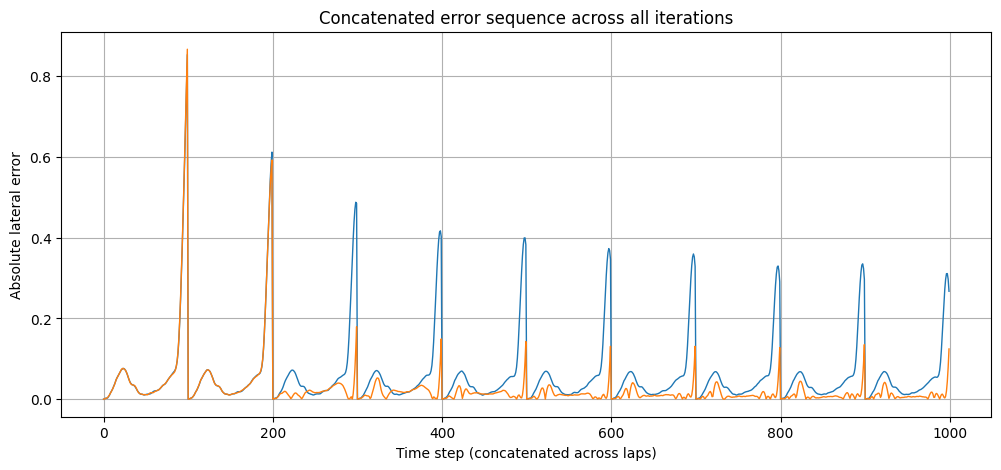

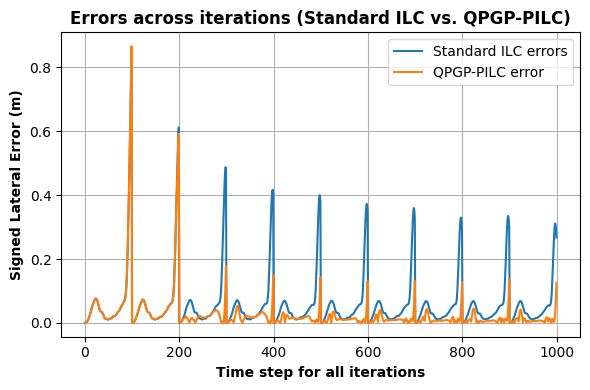

In [5]:
n_points = 100
dt = 0.05
v = 2
L = 0.5
n_iter = 10
K = 1
np.random.seed(1)

print(v*dt*n_points)
x_ref, y_ref = create_race_track(n_points, v*dt*n_points)

# Standard
theta0 = np.arctan2(y_ref[1] - y_ref[0], x_ref[1] - x_ref[0])
delta_ff = np.zeros(n_points)
np.random.seed(1)
trajectories_np = []
mean_errors_per_lap_np = []
error_matrix_np = np.zeros((n_iter, n_points))  # to store errors over iterations and time steps

for iteration in range(n_iter):
    x0, y0 = x_ref[0], y_ref[0]
    x_actual, y_actual, delta_actual = simulate_car(
        x0, y0, theta0, v, delta_ff, x_ref, y_ref, dt, n_points, L)

    # Compute signed lateral error at each timestep
    errors = np.zeros(n_points)
    for k in range(n_points):
        errors[k] = signed_lateral_error(x_ref, y_ref, x_actual[k], y_actual[k])

    # Update feedforward steering with signed lateral error - the basic idea is to compensate for the error on the next run using these predicted errors
    delta_ff -= K/(1+iteration) * errors

    error_matrix_np[iteration, :] = np.abs(errors)
    trajectories_np.append((x_actual.copy(), y_actual.copy()))

    mean_err = np.mean(np.abs(errors))
    print(f"Iteration {iteration+1}, mean signed lateral error: {mean_err:.4f}")
    mean_errors_per_lap_np.append(mean_err)


# QPGP

# Simulation Parameters

theta0 = np.arctan2(y_ref[1] - y_ref[0], x_ref[1] - x_ref[0])
delta_ff = np.zeros(n_points)

trajectories_qpgp = []
Y_gp = []

Kp = 35
error_matrix_qpgp = np.zeros((n_iter, n_points))  # store per-time-step errors
mean_errors_per_lap_qpgp = []  # store per-lap mean errors
#start_time = time.time()
for iteration in range(n_iter):
    x0, y0 = x_ref[0], y_ref[0]
    x_actual, y_actual, delta_actual = simulate_car(
        x0, y0, theta0, v, delta_ff, x_ref, y_ref, dt, n_points, L)

    # Compute signed lateral error
    errors_qpgp = np.zeros(n_points)
    for k in range(n_points):
        errors_qpgp[k] = signed_lateral_error(x_ref, y_ref, x_actual[k], y_actual[k])

    Y_gp.append(errors_qpgp.reshape(-1, 1))
    Y_gp = Y_gp[-n_points:]
    Y_data = np.vstack(Y_gp).flatten()

    if iteration < 1:
        delta_ff -= (K/(iteration+1)) * errors_qpgp  # raw-error ILC
    else:
        est_par = par_est(len(Y_data), [n_points], Y_data)
        pred_error = pred_block(len(Y_data), n_points, est_par['w'], Y_data)
        delta_ff -= Kp/((iteration+1)) * pred_error + K/((iteration+1)) * errors_qpgp  # GP-based ILC

    error_matrix_qpgp[iteration, :] = np.abs(errors_qpgp)
    trajectories_qpgp.append((x_actual.copy(), y_actual.copy()))
    mean_err = np.mean(np.abs(errors_qpgp))
    mean_errors_per_lap_qpgp.append(mean_err)

    print(f"Iteration {iteration+1}, mean signed lateral error: {mean_err:.4f}")
#end_time = time.time()
#print(f"Total time taken: {end_time - start_time:.2f} seconds")

import matplotlib.pyplot as plt
all_errors_np = error_matrix_np.flatten()
all_errors_qpgp = error_matrix_qpgp.flatten()

plt.figure(figsize=(12, 5))
plt.plot(all_errors_np, lw=1)
plt.plot(all_errors_qpgp, lw=1)
plt.xlabel("Time step (concatenated across laps)")
plt.ylabel("Absolute lateral error")
plt.title("Concatenated error sequence across all iterations")
plt.grid(True)
plt.show()


import matplotlib.pyplot as plt

fig_width = 6
fig_height = 4
plt.figure(figsize=(fig_width, fig_height))

all_errors_np = error_matrix_np.flatten()
all_errors_qpgp = error_matrix_qpgp.flatten()

plt.plot(all_errors_np, lw=1.5, label="Standard ILC errors")
plt.plot(all_errors_qpgp, lw=1.5, label="QPGP-PILC error")

plt.xlabel("Time step for all iterations", fontweight='bold')
plt.ylabel("Signed Lateral Error (m)", fontweight='bold')
plt.title("Errors across iterations (Standard ILC vs. QPGP-PILC)", fontweight='bold')

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("fig1.pdf", format="pdf", bbox_inches="tight")

plt.show()

# Parameter

In [6]:
n_points = 100
dt = 0.025
v = 8
L = 0.5
n_iter = 100
K = 0.5
np.random.seed(1)
x_ref, y_ref = create_race_track(n_points, v*dt*n_points)

# Standard ILC

In [7]:
# Simualtion Parameters
theta0 = np.arctan2(y_ref[1] - y_ref[0], x_ref[1] - x_ref[0])
delta_ff = np.zeros(n_points)

trajectories_np = []
mean_errors_per_lap_np = []
error_matrix = np.zeros((n_iter, n_points))  # to store errors over iterations and time steps

for iteration in range(n_iter):
    x0, y0 = x_ref[0], y_ref[0]
    x_actual, y_actual, delta_actual = simulate_car(
        x0, y0, theta0, v, delta_ff, x_ref, y_ref, dt, n_points, L)

    # Compute signed lateral error at each timestep
    errors = np.zeros(n_points)
    for k in range(n_points):
        errors[k] = signed_lateral_error(x_ref, y_ref, x_actual[k], y_actual[k])

    # Update feedforward steering with signed lateral error - the basic idea is to compensate for the error on the next run using these predicted errors
    delta_ff -= K/(1+iteration) * errors

    error_matrix[iteration, :] = np.abs(errors)
    trajectories_np.append((x_actual.copy(), y_actual.copy()))

    mean_err = np.mean(np.abs(errors))
    print(f"Iteration {iteration+1}, mean signed lateral error: {mean_err:.4f}")
    mean_errors_per_lap_np.append(mean_err)


Iteration 1, mean signed lateral error: 0.2462
Iteration 2, mean signed lateral error: 0.1547
Iteration 3, mean signed lateral error: 0.1225
Iteration 4, mean signed lateral error: 0.1106
Iteration 5, mean signed lateral error: 0.1057
Iteration 6, mean signed lateral error: 0.1062
Iteration 7, mean signed lateral error: 0.1039
Iteration 8, mean signed lateral error: 0.1021
Iteration 9, mean signed lateral error: 0.1020
Iteration 10, mean signed lateral error: 0.1007
Iteration 11, mean signed lateral error: 0.1010
Iteration 12, mean signed lateral error: 0.1013
Iteration 13, mean signed lateral error: 0.0995
Iteration 14, mean signed lateral error: 0.1009
Iteration 15, mean signed lateral error: 0.1001
Iteration 16, mean signed lateral error: 0.0965
Iteration 17, mean signed lateral error: 0.0984
Iteration 18, mean signed lateral error: 0.0965
Iteration 19, mean signed lateral error: 0.0972
Iteration 20, mean signed lateral error: 0.0958
Iteration 21, mean signed lateral error: 0.0956
I

# QPGP (block-wise) PILC

In [8]:
import time

Kp=1
theta0 = np.arctan2(y_ref[1] - y_ref[0], x_ref[1] - x_ref[0])
delta_ff = np.zeros(n_points)

trajectories_qpgp_block = []
Y_gp = []

error_matrix_qpgp_block = np.zeros((n_iter, n_points))  # store per-time-step errors
mean_errors_per_lap_qpgp_block = []  # store per-lap mean errors
start_time_qpgp_block = time.time()
for iteration in range(n_iter):
    x0, y0 = x_ref[0], y_ref[0]
    x_actual, y_actual, delta_actual = simulate_car(
        x0, y0, theta0, v, delta_ff, x_ref, y_ref, dt, n_points, L)

    # Compute signed lateral error
    errors_qpgp_block = np.zeros(n_points)
    for k in range(n_points):
        errors_qpgp_block[k] = signed_lateral_error(x_ref, y_ref, x_actual[k], y_actual[k])

    Y_gp.append(errors_qpgp_block.reshape(-1, 1))
    Y_gp = Y_gp#[-5*n_points:]
    Y_data = np.vstack(Y_gp).flatten()

    if iteration < 1:
        delta_ff -= (K/(iteration+1)) * errors_qpgp_block  # raw-error ILC
    else:
        est_par = par_est(len(Y_data), [n_points], Y_data)
        pred_error = pred_block(len(Y_data), n_points, est_par['w'], Y_data)
        delta_ff -= Kp/((iteration+1)) * pred_error + K/((iteration+1)) * errors_qpgp_block  # GP-based ILC

    error_matrix_qpgp_block[iteration, :] = np.abs(errors_qpgp_block)
    trajectories_qpgp_block.append((x_actual.copy(), y_actual.copy()))
    mean_err = np.mean(np.abs(errors_qpgp_block))
    mean_errors_per_lap_qpgp_block.append(mean_err)

    print(f"Iteration {iteration+1}, mean signed lateral error: {mean_err:.4f}")
end_time_qpgp_block = time.time()
time_qpgp_block = end_time_qpgp_block - start_time_qpgp_block
print(f"Total time taken: {time_qpgp_block:.2f} seconds")

Iteration 1, mean signed lateral error: 0.2430
Iteration 2, mean signed lateral error: 0.1646
Iteration 3, mean signed lateral error: 0.1051
Iteration 4, mean signed lateral error: 0.0982
Iteration 5, mean signed lateral error: 0.0911
Iteration 6, mean signed lateral error: 0.0904
Iteration 7, mean signed lateral error: 0.0891
Iteration 8, mean signed lateral error: 0.0872
Iteration 9, mean signed lateral error: 0.0852
Iteration 10, mean signed lateral error: 0.0775
Iteration 11, mean signed lateral error: 0.0750
Iteration 12, mean signed lateral error: 0.0749
Iteration 13, mean signed lateral error: 0.0726
Iteration 14, mean signed lateral error: 0.0717
Iteration 15, mean signed lateral error: 0.0714
Iteration 16, mean signed lateral error: 0.0722
Iteration 17, mean signed lateral error: 0.0694
Iteration 18, mean signed lateral error: 0.0714
Iteration 19, mean signed lateral error: 0.0712
Iteration 20, mean signed lateral error: 0.0694
Iteration 21, mean signed lateral error: 0.0684
I

# QPGP (element-wise) PILC

In [9]:
import time
Kp=1
theta0 = np.arctan2(y_ref[1] - y_ref[0], x_ref[1] - x_ref[0])
delta_ff = np.zeros(n_points)

trajectories_qpgp_element = []
Y_gp = []

error_matrix_qpgp_element = np.zeros((n_iter, n_points))  # store per-time-step errors
mean_errors_per_lap_qpgp_element = []  # store per-lap mean errors
start_time_qpgp_element = time.time()
for iteration in range(n_iter):
    x0, y0 = x_ref[0], y_ref[0]
    x_actual, y_actual, delta_actual = simulate_car(
        x0, y0, theta0, v, delta_ff, x_ref, y_ref, dt, n_points, L)

    # Compute signed lateral error
    errors_qpgp_element = np.zeros(n_points)
    for k in range(n_points):
        errors_qpgp_element[k] = signed_lateral_error(x_ref, y_ref, x_actual[k], y_actual[k])

    Y_gp.append(errors_qpgp_element.reshape(-1, 1))
    Y_gp = Y_gp#[-5*n_points:]
    Y_data = np.vstack(Y_gp).flatten()

    if iteration < 1:
        delta_ff -= (K/(iteration+1)) * errors_qpgp_element  # raw-error ILC
    else:
        est_par = par_est(len(Y_data), [n_points], Y_data)
        pred_error_element = np.zeros(n_points)
        for t in range(n_points):
            pred_error_element[t] = pred_element(len(Y_data) - n_points + t, n_points, est_par['w'], est_par['Kappa'], Y_data)
        delta_ff -= Kp/((iteration+1)) * pred_error_element + K/((iteration+1)) * errors_qpgp_element  # GP-based ILC

    error_matrix_qpgp_element[iteration, :] = np.abs(errors_qpgp_element)
    trajectories_qpgp_element.append((x_actual.copy(), y_actual.copy()))
    mean_err = np.mean(np.abs(errors_qpgp_element))
    mean_errors_per_lap_qpgp_element.append(mean_err)

    print(f"Iteration {iteration+1}, mean signed lateral error: {mean_err:.4f}")
end_time_qpgp_element = time.time()
time_qpgp_element = end_time_qpgp_element - start_time_qpgp_element
print(f"Total time taken: {time_qpgp_element:.2f} seconds")

Iteration 1, mean signed lateral error: 0.2488
Iteration 2, mean signed lateral error: 0.1506
Iteration 3, mean signed lateral error: 0.0972
Iteration 4, mean signed lateral error: 0.0811
Iteration 5, mean signed lateral error: 0.0762
Iteration 6, mean signed lateral error: 0.0678
Iteration 7, mean signed lateral error: 0.0654
Iteration 8, mean signed lateral error: 0.0620
Iteration 9, mean signed lateral error: 0.0605
Iteration 10, mean signed lateral error: 0.0596
Iteration 11, mean signed lateral error: 0.0586
Iteration 12, mean signed lateral error: 0.0571
Iteration 13, mean signed lateral error: 0.0572
Iteration 14, mean signed lateral error: 0.0566
Iteration 15, mean signed lateral error: 0.0561
Iteration 16, mean signed lateral error: 0.0564
Iteration 17, mean signed lateral error: 0.0522
Iteration 18, mean signed lateral error: 0.0539
Iteration 19, mean signed lateral error: 0.0501
Iteration 20, mean signed lateral error: 0.0497
Iteration 21, mean signed lateral error: 0.0491
I

# GP-PILC

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

Kp=0.4
# --- Parameters ---
mean_errors_per_lap_gp = []
error_matrix_gp = np.zeros((n_iter, n_points))

theta0 = np.arctan2(y_ref[1] - y_ref[0], x_ref[1] - x_ref[0])
delta_ff = np.zeros(n_points)
error_matrix_gp = np.zeros((n_iter, n_points))
mean_errors_per_lap_gp = []
Y_gp = []
trajectories_gp = []   # <-- store trajectories

# Define GP model with flexible kernel
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, ConstantKernel

#kernel =(
 #   RBF(length_scale=1.0, length_scale_bounds=(0.1, 3.0)) *
  #  ExpSineSquared(length_scale=1.0, periodicity=n_points,
   #                length_scale_bounds=(0.1, 3.0),
    #               periodicity_bounds=(n_points, n_points)))+ WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-4, 1e-2))

# Just RBF
kernel = RBF(length_scale=1, length_scale_bounds=(1e-2, 100)) + WhiteKernel(noise_level=1e-2, noise_level_bounds=(1e-2, 1e-1))
gp_model = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, normalize_y=False) 
start_time_gp = time.time()
for iteration in range(n_iter):
    x0, y0 = x_ref[0], y_ref[0]
    x_actual, y_actual, delta_actual = simulate_car(
        x0, y0, theta0, v, delta_ff, x_ref, y_ref, dt, n_points, L)

    errors_gp = np.array([signed_lateral_error(x_ref, y_ref, x_actual[k], y_actual[k])
                          for k in range(n_points)])

    Y_gp.append(errors_gp.reshape(-1, 1))
    Y_data = np.vstack(Y_gp)

    if iteration < 1:   # warmup
        delta_ff -= (K/(iteration+1)) * errors_gp
    else:
        # Train indices = all but last lap
        #y_train = Y_data[-5*n_points:].ravel()
        y_train = Y_data.ravel()
        X_train = np.arange(len(y_train)).reshape(-1, 1)
        # Test on the same horizon (predict next lap)
        X_test = np.arange(n_points).reshape(-1, 1)

        # Fit GP on last lap
        gp_model.fit(X_train, y_train)

        # Predict error for next lap
        pred_error, _ = gp_model.predict(X_test, return_std=True)

        delta_ff -= (Kp/(iteration+1)) * pred_error.flatten() \
                    + ((K)/(iteration+1)) * errors_gp

    error_matrix_gp[iteration, :] = np.abs(errors_gp)
    trajectories_gp.append((x_actual.copy(), y_actual.copy()))
    mean_err = np.mean(np.abs(errors_gp))
    mean_errors_per_lap_gp.append(mean_err)


    print(f"Iter {iteration+1:2d} | GP mean error:   {mean_err:.4f}")
end_time_gp = time.time()
time_gp = end_time_gp - start_time_gp
print(f"Total time taken: {time_gp:.2f} seconds")

Iter  1 | GP mean error:   0.2417
Iter  2 | GP mean error:   0.1496
Iter  3 | GP mean error:   0.1079
Iter  4 | GP mean error:   0.1040
Iter  5 | GP mean error:   0.1017
Iter  6 | GP mean error:   0.0967
Iter  7 | GP mean error:   0.0967
Iter  8 | GP mean error:   0.0957
Iter  9 | GP mean error:   0.0950
Iter 10 | GP mean error:   0.0863
Iter 11 | GP mean error:   0.0864
Iter 12 | GP mean error:   0.0848
Iter 13 | GP mean error:   0.0835
Iter 14 | GP mean error:   0.0839
Iter 15 | GP mean error:   0.0851
Iter 16 | GP mean error:   0.0837
Iter 17 | GP mean error:   0.0841
Iter 18 | GP mean error:   0.0838
Iter 19 | GP mean error:   0.0841
Iter 20 | GP mean error:   0.0794
Iter 21 | GP mean error:   0.0727
Iter 22 | GP mean error:   0.0822
Iter 23 | GP mean error:   0.0719
Iter 24 | GP mean error:   0.0710
Iter 25 | GP mean error:   0.0705
Iter 26 | GP mean error:   0.0707
Iter 27 | GP mean error:   0.0696
Iter 28 | GP mean error:   0.0695
Iter 29 | GP mean error:   0.0692
Iter 30 | GP m

# Sparse GP-PILC

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'svg'
import GPy
import time


# --- Storage ---
error_matrix_sparse = np.zeros((n_iter, n_points))
mean_errors_per_lap_sparse = []
Y_sparse = []
trajectories_sparse = []

# --- Initial feedforward & heading ---
theta0 = np.arctan2(y_ref[1] - y_ref[0], x_ref[1] - x_ref[0])
delta_ff = np.zeros(n_points)

# --- Initialize Sparse GP once ---
# Start with zero errors for warm-up
num_inducing = 100
X_train_init = np.arange(n_points).reshape(-1,1)
y_train_init = np.zeros((n_points,1))
Z_init = np.linspace(0, n_points-1, num_inducing)[:,None]

sparse_model = GPy.models.SparseGPRegression(X_train_init, y_train_init, Z=Z_init)
sparse_model.likelihood.variance = 1e-5
sparse_model.Z.unconstrain()  # allow inducing points to move

# Optional: randomize hyperparameters initially
sparse_model.randomize()
sparse_model.optimize('bfgs', max_iters=500, messages=False)

# --- Main loop ---
start_time_sparse = time.time()
for iteration in range(n_iter):
    # Simulate car trajectory
    x0, y0 = x_ref[0], y_ref[0]
    x_actual, y_actual, delta_actual = simulate_car(
        x0, y0, theta0, v, delta_ff, x_ref, y_ref, dt, n_points, L)

    # Compute errors for this lap
    errors_sparse = np.array([
        signed_lateral_error(x_ref, y_ref, x_actual[k], y_actual[k])
        for k in range(n_points)
    ])

    # Accumulate error history
    Y_sparse.append(errors_sparse.reshape(-1,1))
    Y_data = np.vstack(Y_sparse)

    if iteration < 1:  # warm-up lap
        delta_ff -= (K/(iteration+1)) * errors_sparse
    else:
        # --- Update GP training data ---
        y_train = Y_data.ravel()
        X_train = np.arange(len(y_train)).reshape(-1,1)
        X_test = np.arange(n_points).reshape(-1,1)

        sparse_model.set_XY(X_train, y_train.reshape(-1,1))
        sparse_model.optimize('bfgs', max_iters=300, messages=False)

        # Predict error for next lap
        pred_mean, pred_std = sparse_model.predict(X_test)
        pred_error = pred_mean.flatten()

        # Update feedforward control
        delta_ff -= (Kp/(iteration+1)) * pred_error + (K/(iteration+1)) * errors_sparse

    # --- Store statistics ---
    error_matrix_sparse[iteration, :] = np.abs(errors_sparse)
    trajectories_sparse.append((x_actual.copy(), y_actual.copy()))
    mean_err = np.mean(np.abs(errors_sparse))
    mean_errors_per_lap_sparse.append(mean_err)

    print(f"Iter {iteration+1:2d} | Sparse GP mean error: {mean_err:.4f}")

end_time_sparse = time.time()
time_sparse = end_time_sparse - start_time_sparse
print(f"Total time taken (Sparse GP with optimized inducing points): {time_sparse:.2f} seconds")


# Plots

In [ ]:
print(f"NP Time: {time_np:.2f} seconds")
print(f"QPGP Block Time: {time_qpgp_block:.2f} seconds")
print(f"QPGP Element Time: {time_qpgp_element:.2f} seconds")
print(f"GP Time: {time_gp:.2f} seconds")
print(f"Sparse GP Time: {time_sparse:.2f} seconds")


import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.plot(mean_errors_per_lap_qpgp_element, label='Element QPGP')
plt.plot(mean_errors_per_lap_qpgp_block, label= 'Block QPGP')
plt.plot(mean_errors_per_lap_gp, label= 'GP')
plt.plot(mean_errors_per_lap_np, label= 'NP')
plt.plot(mean_errors_per_lap_sparse, label= 'Sparse')

plt.xlabel('Iteration')
plt.ylabel('Mean Abs. Error ')
plt.title('Mean Abs. Error (Comparison)')
plt.legend()
plt.grid(True)
plt.show()


import matplotlib.pyplot as plt

# --- IEEE double-column size ---
fig_width = 7.16  # inches
fig_height = 4.0  # proportional height
plt.figure(figsize=(fig_width, fig_height))

# --- Plot data ---
plt.plot(mean_errors_per_lap_np, linewidth=2, color="C0", label="Standard ILC")
plt.plot(mean_errors_per_lap_qpgp_block, linewidth=2, color="C1", label="QPGP-PILC (general kernel, Block prediction)")
plt.plot(mean_errors_per_lap_qpgp_element, linewidth=2, color="C2", label="QPGP-PILC (general kernel, Element prediction)")
plt.plot(mean_errors_per_lap_gp, linewidth=2, color="C4", label="GP-PILC (RBF kernel)")
plt.plot(mean_errors_per_lap_sparse, linewidth=2, color="C5", label="Sparse GP (RBF kernel)")


# --- Labels and title ---
plt.xlabel("Iteration No.", fontsize=10)
plt.ylabel("Mean Abs. Error (m)", fontsize=10)
plt.title("Mean Absolute Error Comparison", fontsize=11, fontweight="bold")

# --- Axes limits, grid, and legend ---
plt.ylim([0.025,0.14])
plt.xlim(1, 100)  # Force x-axis to show 1 to 100
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=9, loc="upper right", frameon=True)

plt.tight_layout()

# --- Save as PDF BEFORE showing ---
plt.savefig("car_error.pdf", format="pdf", bbox_inches="tight")

# Show figure
plt.show()
